Part A: Dataset Understanding

1. Domain of the Dataset

This dataset is related to lifestyle and sustainability. It shows how people live their daily lives and how their habits affect the environment, like energy use, travel, and waste.

3. Explain why normalization is required for the selected dataset.

Normalization is necessary because the dataset includes numerical features with different units and scales (e.g., income vs. water usage). Without normalization, features with larger values can dominate the analysis and bias the results. Scaling ensures all variables contribute equally, leading to more accurate and reliable model performance.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("lifestyle_sustainability_data.csv")

# View data
df.head()

Saving lifestyle_sustainability_data.csv to lifestyle_sustainability_data.csv


,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
1,2,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,True,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
3,4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
4,5,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,True,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3


In [ ]:
df.columns
df.nunique()
df.describe()

,ParticipantID,Age,HomeSize,EnvironmentalAwareness,MonthlyElectricityConsumption,MonthlyWaterConsumption,Rating
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,250.024048,44.052104,1518.046092,3.062124,291.963928,3139.521042,3.430862
std,144.233925,14.904828,672.212235,1.342145,120.482275,1224.609306,1.502585
min,1.000000,18.000000,407.000000,1.000000,55.000000,536.000000,1.000000
25%,125.500000,31.000000,951.500000,2.000000,185.000000,2000.000000,2.000000
50%,250.000000,44.000000,1450.000000,3.000000,295.000000,3350.000000,4.000000
75%,374.500000,58.000000,1995.000000,4.000000,400.000000,4100.000000,5.000000
max,500.000000,96.000000,2997.000000,5.000000,498.000000,5250.000000,5.000000


In [ ]:
# Inspect dataset
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   ParticipantID                  499 non-null    int64 
 1   Age                            499 non-null    int64 
 2   Location                       499 non-null    object
 3   DietType                       499 non-null    object
 4   LocalFoodFrequency             499 non-null    object
 5   TransportationMode             499 non-null    object
 6   EnergySource                   499 non-null    object
 7   HomeType                       499 non-null    object
 8   HomeSize                       499 non-null    int64 
 9   ClothingFrequency              499 non-null    object
 10  SustainableBrands              499 non-null    bool  
 11  EnvironmentalAwareness         499 non-null    int64 
 12  CommunityInvolvement           381 non-null    object
 13  Month

,ParticipantID,Age,HomeSize,EnvironmentalAwareness,MonthlyElectricityConsumption,MonthlyWaterConsumption,Rating
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,250.024048,44.052104,1518.046092,3.062124,291.963928,3139.521042,3.430862
std,144.233925,14.904828,672.212235,1.342145,120.482275,1224.609306,1.502585
min,1.000000,18.000000,407.000000,1.000000,55.000000,536.000000,1.000000
25%,125.500000,31.000000,951.500000,2.000000,185.000000,2000.000000,2.000000
50%,250.000000,44.000000,1450.000000,3.000000,295.000000,3350.000000,4.000000
75%,374.500000,58.000000,1995.000000,4.000000,400.000000,4100.000000,5.000000
max,500.000000,96.000000,2997.000000,5.000000,498.000000,5250.000000,5.000000


2.List all numerical and categorical attributes.



In [ ]:


# Fill categorical missing values with mode
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values with median (more robust than mean)
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())



,0
ParticipantID,0
Age,0
Location,0
DietType,0
LocalFoodFrequency,0
TransportationMode,0
EnergySource,0
HomeType,0
HomeSize,0
ClothingFrequency,0


Part B: Data Preparation

1.Load and inspect the dataset.
2.Handle missing values.
3.Remove duplicate records





In [37]:
# Check missing values
df.isnull().sum()

# Verify again
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

# Confirm
df.duplicated().sum()

np.int64(0)

In [ ]:
features = df.select_dtypes(include=np.number).columns.tolist()

if 'ParticipantID' in features:
    features.remove('ParticipantID')

print("Selected Features:", features)

Selected Features: ['Age', 'HomeSize', 'EnvironmentalAwareness', 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption', 'Rating', 'TotalConsumption']


In [ ]:
df['TotalConsumption'] = df['MonthlyElectricityConsumption'] + df['MonthlyWaterConsumption']

4. visualization before and after normalization (Bar graph, Box Plot, Line graph …..)


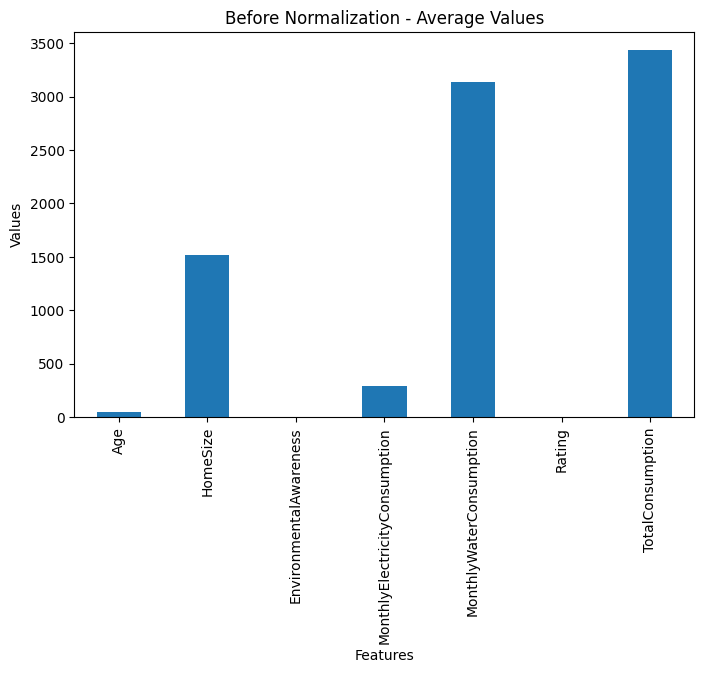

In [ ]:
# BAR GRAPH (Average consumption comparison)
plt.figure(figsize=(8,5))
df[features].mean().plot(kind='bar')
plt.title("Before Normalization - Average Values")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

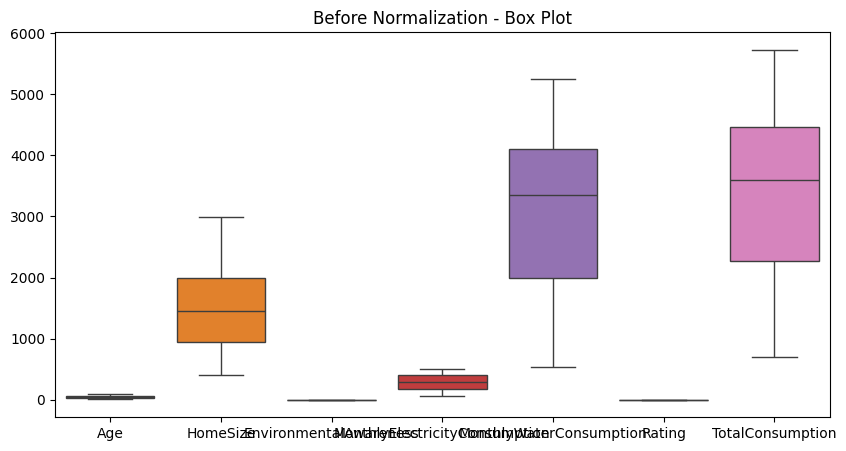

In [ ]:
# BOX PLOT (Check outliers in sustainability data)
plt.figure(figsize=(10,5))
sns.boxplot(data=df[features])
plt.title("Before Normalization - Box Plot")
plt.show()

<Figure size 1000x500 with 0 Axes>

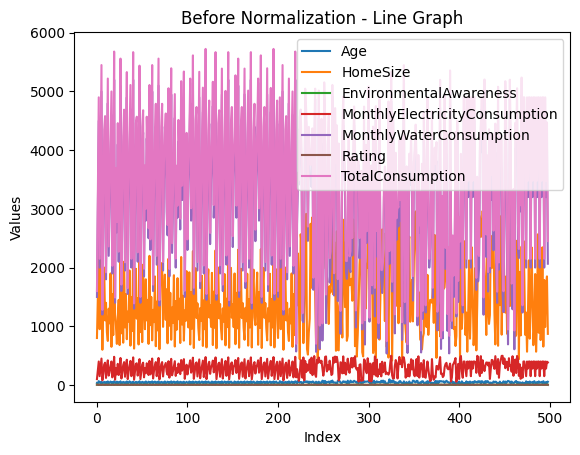

In [ ]:
# LINE GRAPH (Trend across dataset)
plt.figure(figsize=(10,5))
df[features].plot()
plt.title("Before Normalization - Line Graph")
plt.xlabel("Index")
plt.ylabel("Values")
plt.show()

Min-Max Normalization


In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[features] = minmax.fit_transform(df[features])

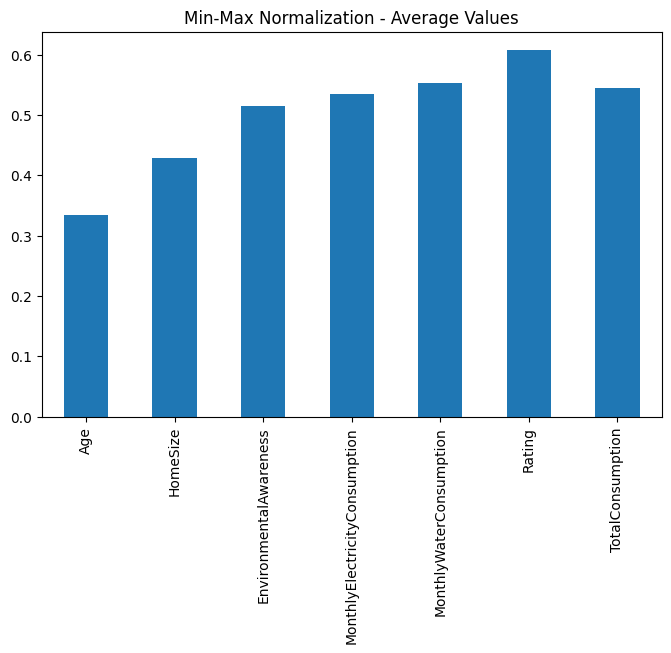

In [ ]:
# BAR GRAPH
plt.figure(figsize=(8,5))
df_minmax[features].mean().plot(kind='bar')
plt.title("Min-Max Normalization - Average Values")
plt.show()

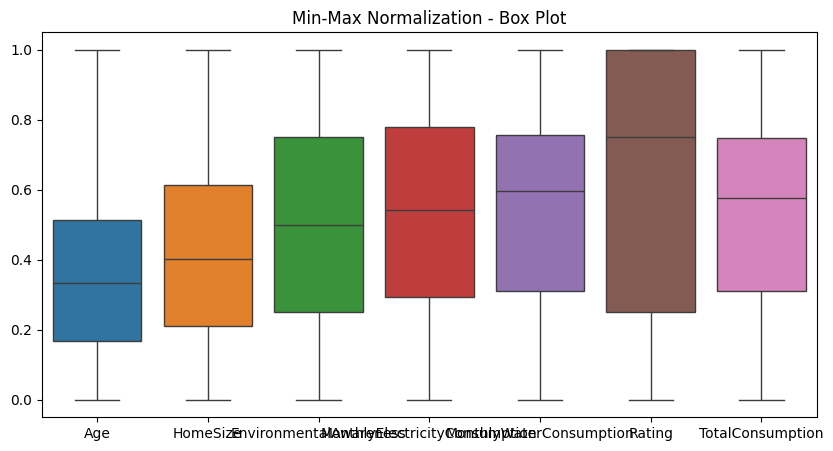

In [ ]:

# BOX PLOT
plt.figure(figsize=(10,5))
sns.boxplot(data=df_minmax[features])
plt.title("Min-Max Normalization - Box Plot")
plt.show()

<Figure size 1000x500 with 0 Axes>

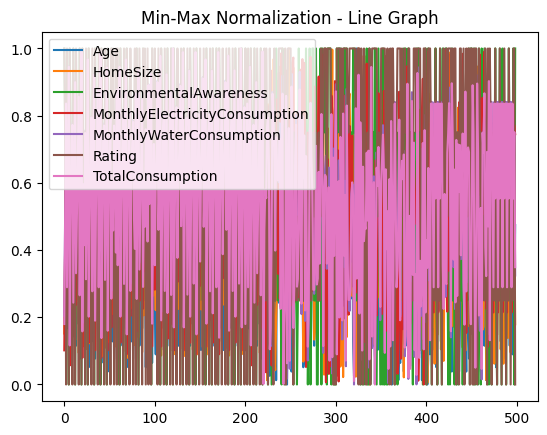

In [ ]:
# LINE GRAPH
plt.figure(figsize=(10,5))
df_minmax[features].plot()
plt.title("Min-Max Normalization - Line Graph")
plt.show()

Part C: Normalization Techniques

Min-Max Normalization:

Scale the values between 0 and 1.


In [27]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("lifestyle_sustainability_data.csv")

# Select numerical columns automatically
features = df.select_dtypes(include='number').columns.tolist()

# initialize scaler (0 to 1 by default)
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply Min-Max Scaling
scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[features] = scaler.fit_transform(df[features])



In [26]:

# Comparison (first 5 rows)
comparison = pd.concat([df[features], df_minmax[features]], axis=1, keys=['Original', 'Normalized'])

comparison.head()

Original                                      \
  ParticipantID Age HomeSize EnvironmentalAwareness   
0             1  35      800                      5   
1             2  28     1500                      4   
2             3  65     2500                      2   
3             4  42      950                      4   
4             5  31     1800                      3   

                                                                  Normalized  \
  MonthlyElectricityConsumption MonthlyWaterConsumption Rating ParticipantID   
0                           100                    1500      5      0.000000   
1                           250                    3000      4      0.002004   
2                           400                    4500      1      0.004008   
3                           150                    2000      5      0.006012   
4                           300                    3500      3      0.008016   

                                                                            \
        Age  HomeSize EnvironmentalAwareness MonthlyElectricityConsumption   
0  0.217949  0.151737                   1.00                      0.101580   
1  0.128205  0.422008                   0.75                      0.440181   
2  0.602564  0.808108                   0.25                      0.778781   
3  0.307692  0.209653                   0.75                      0.214447   
4  0.166667  0.537838                   0.50                      0.553047   

                                  
  MonthlyWaterConsumption Rating  
0                0.204497   1.00  
1                0.522698   0.75  
2                0.840899   0.00  
3                0.310564   1.00  
4                0.628765   0.50

Z-Score Normalization (Standardization)

In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Copy dataset
df_zscore = df.copy()

# Apply Z-score normalization
df_zscore[features] = scaler.fit_transform(df[features])

# View first few rows
df_zscore.head()

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,-1.728262,-0.607936,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,-1.069256,Rarely,True,1.445313,High,-1.594895,-1.340155,Female,Rarely,Composting,High,1.045341
1,-1.721321,-1.078054,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,-0.026873,Sometimes,True,0.699490,Moderate,-0.348649,-0.114045,Male,Sometimes,Recycling,Moderate,0.379153
2,-1.714381,1.406854,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,1.462245,Often,False,-0.792157,Low,0.897597,1.112064,Male,Often,Landfill,Low,-1.619410
3,-1.707441,-0.137819,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,-0.845888,Sometimes,True,0.699490,Moderate,-1.179480,-0.931452,Female,Rarely,Recycling,High,1.045341
4,-1.700501,-0.876575,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,0.419863,Often,True,-0.046334,Low,0.066766,0.294658,Non-Binary,Sometimes,Combination,Moderate,-0.287035


In [29]:
# Check mean and standard deviation
print("Mean after standardization:\n", df_zscore[features].mean())
print("\nStandard deviation after standardization:\n", df_zscore[features].std())

Mean after standardization:
 ParticipantID                   -5.695733e-17
Age                             -1.352737e-16
HomeSize                         4.271800e-17
EnvironmentalAwareness           0.000000e+00
MonthlyElectricityConsumption    1.779917e-16
MonthlyWaterConsumption          1.708720e-16
Rating                           1.423933e-16
dtype: float64

Standard deviation after standardization:
 ParticipantID                    1.001004
Age                              1.001004
HomeSize                         1.001004
EnvironmentalAwareness           1.001004
MonthlyElectricityConsumption    1.001004
MonthlyWaterConsumption          1.001004
Rating                           1.001004
dtype: float64


Part D: Analysis

1.Compare the outputs obtained from different normalization techniques.

Min-Max normalization scales all values between 0 and 1, preserving the original distribution but compressing the range. Z-score normalization transforms data to have a mean of 0 and standard deviation of 1, making it suitable for identifying variations and handling outliers.


Numeric Columns:
 Index(['ParticipantID', 'Age', 'HomeSize', 'EnvironmentalAwareness',
       'MonthlyElectricityConsumption', 'MonthlyWaterConsumption', 'Rating'],
      dtype='object')

Min-Max Scaling Summary:
       ParticipantID         Age    HomeSize  EnvironmentalAwareness  \
count     499.000000  499.000000  499.000000              499.000000   
mean        0.499046    0.334001    0.428975                0.515531   
std         0.289046    0.191088    0.259541                0.335536   
min         0.000000    0.000000    0.000000                0.000000   
25%         0.249499    0.166667    0.210232                0.250000   
50%         0.498998    0.333333    0.402703                0.500000   
75%         0.748497    0.512821    0.613127                0.750000   
max         1.000000    1.000000    1.000000                1.000000   

       MonthlyElectricityConsumption  MonthlyWaterConsumption      Rating  
count                     499.000000               499.000000 

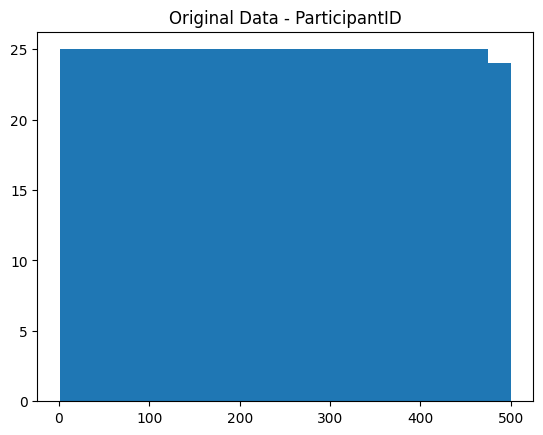

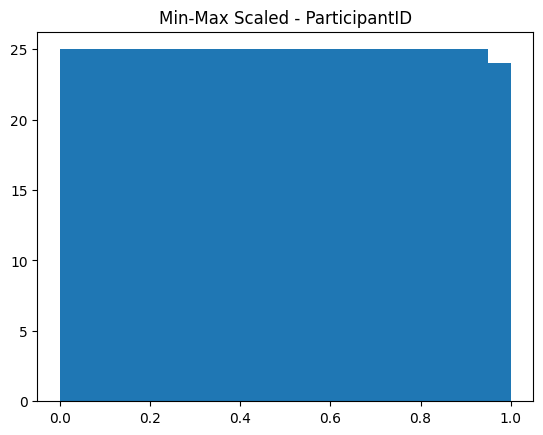

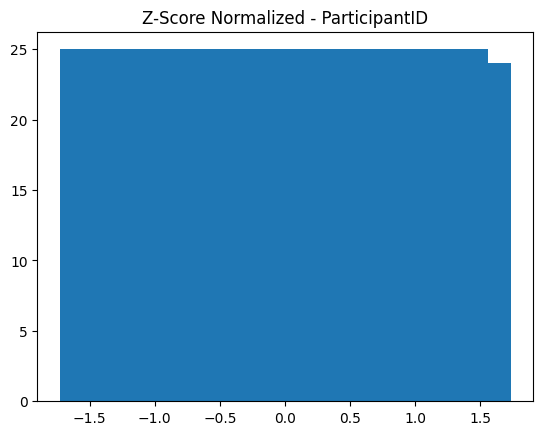

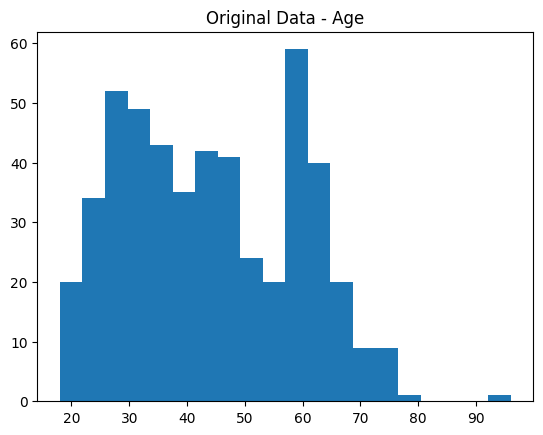

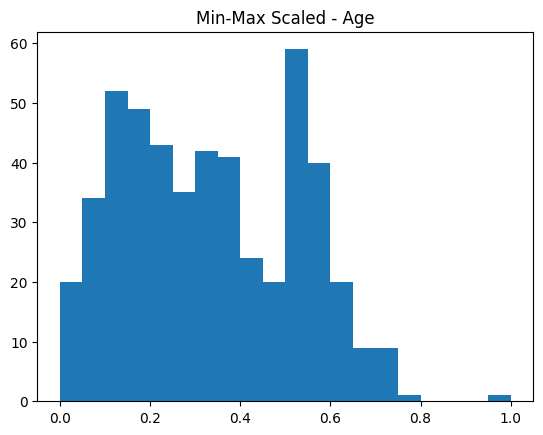

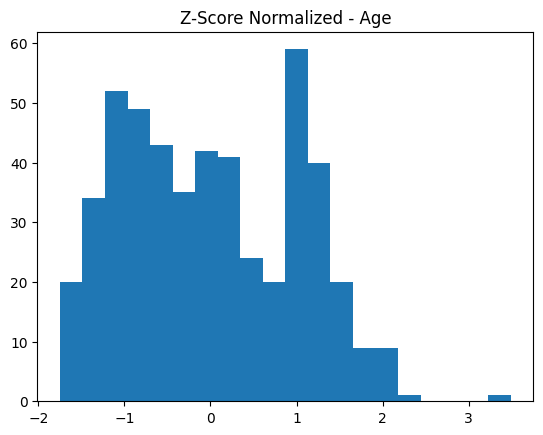

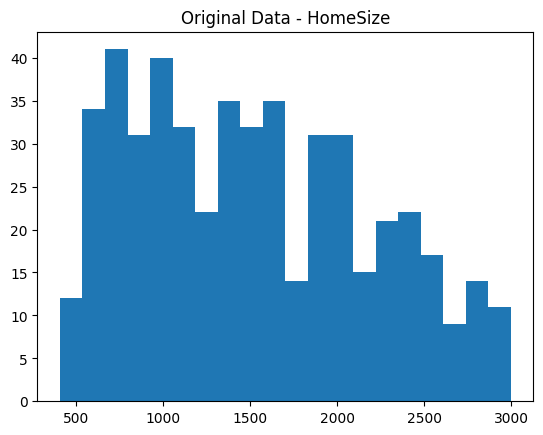

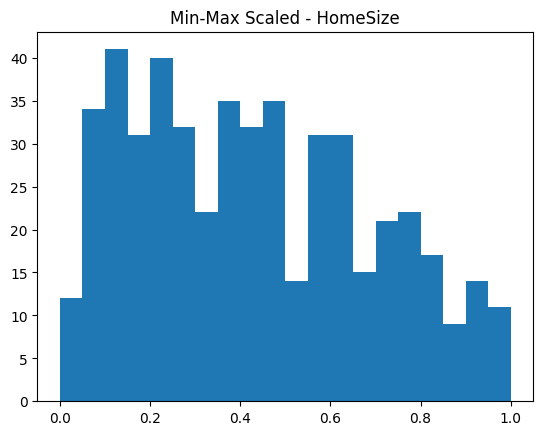

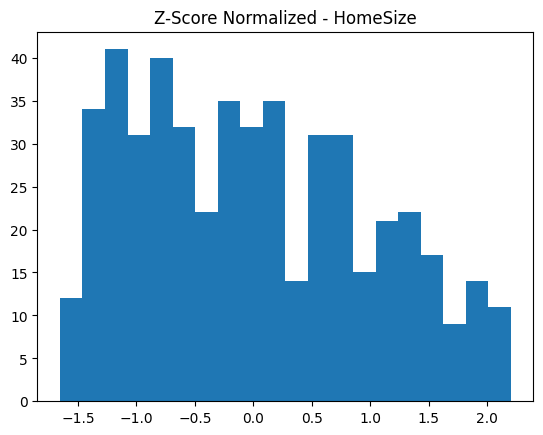

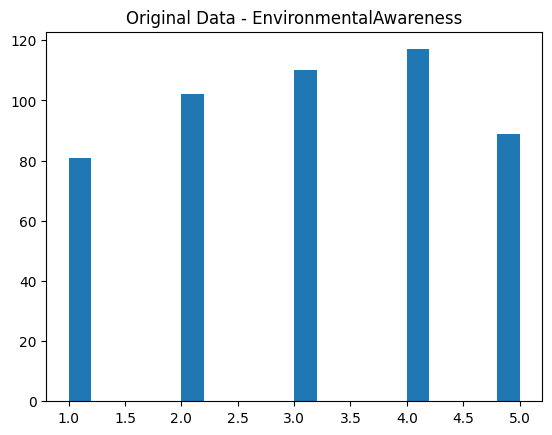

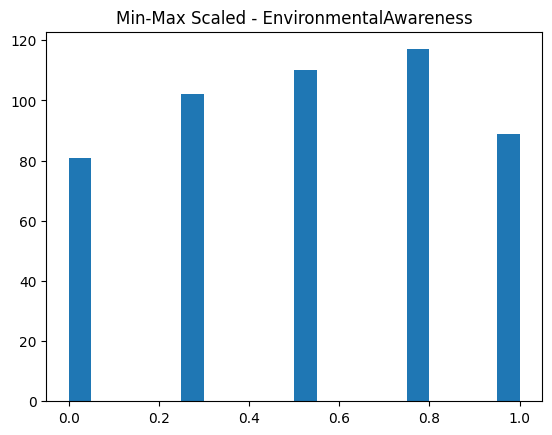

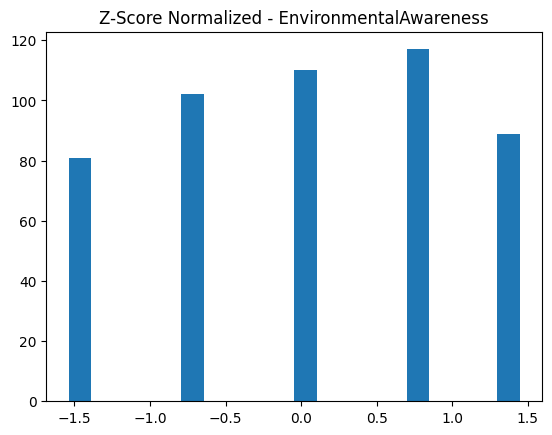

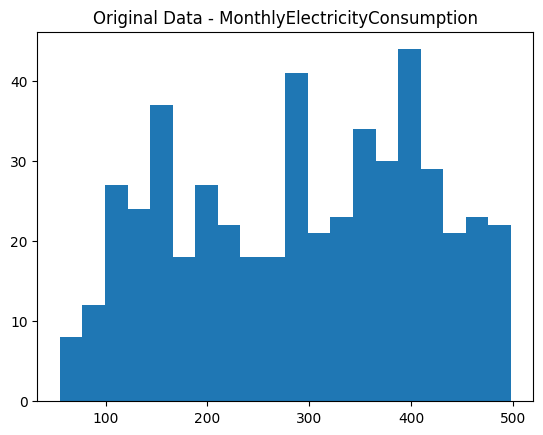

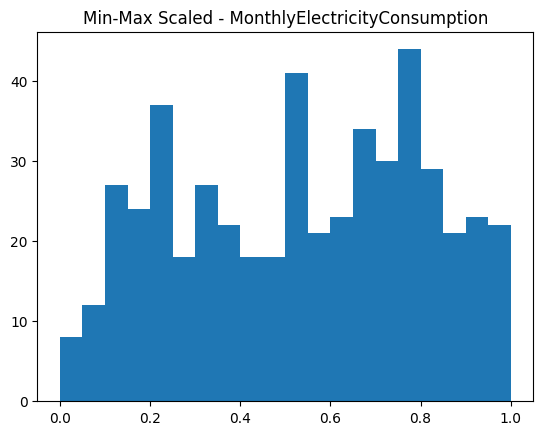

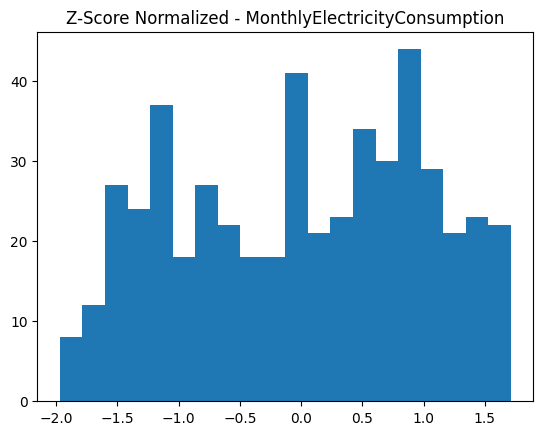

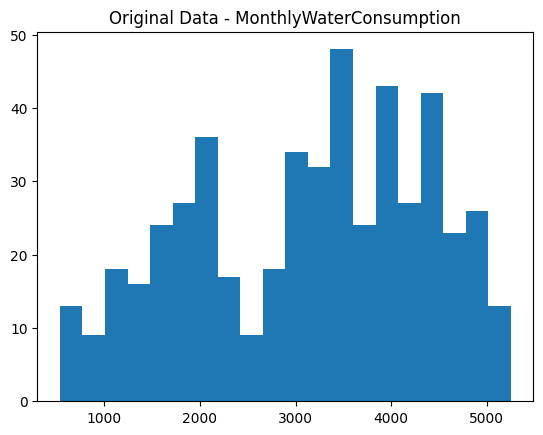

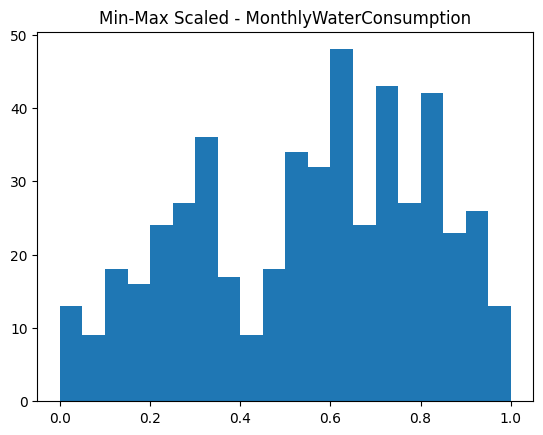

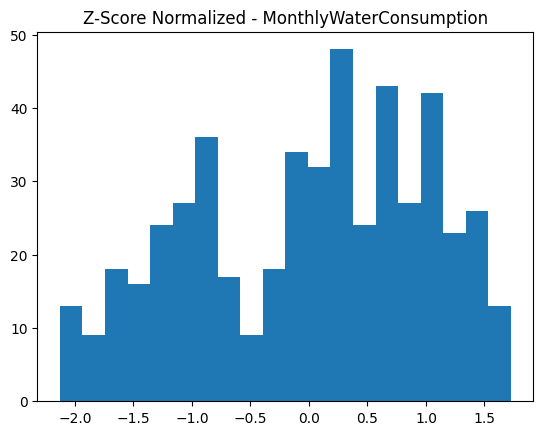

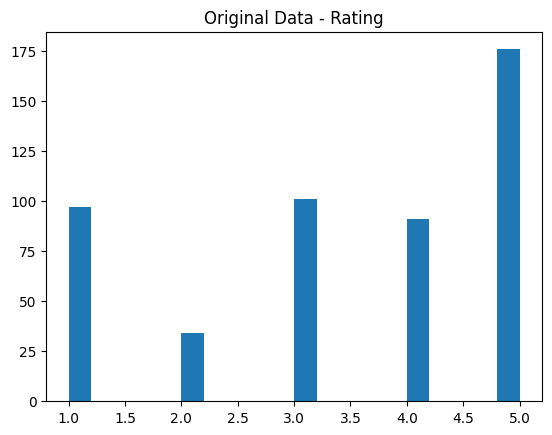

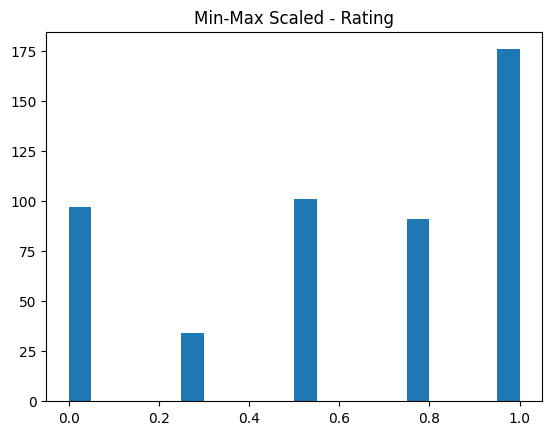

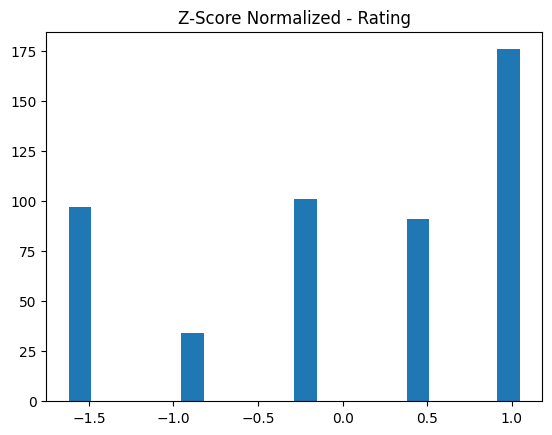

In [36]:
from sklearn.preprocessing import MinMaxScaler
features = df.select_dtypes(include=['number']).columns

print("Numeric Columns:\n", features)
minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[features] = minmax.fit_transform(df[features])

print("\nMin-Max Scaling Summary:")
print(df_minmax[features].describe())

zscore = StandardScaler()

df_zscore = df.copy()
df_zscore[features] = zscore.fit_transform(df[features])

print("\nZ-Score Normalization Summary:")
print(df_zscore[features].describe())

comparison = pd.DataFrame({
    'Min_Max_Mean': df_minmax[features].mean(),
    'Min_Max_Std': df_minmax[features].std(),
    'ZScore_Mean': df_zscore[features].mean(),
    'ZScore_Std': df_zscore[features].std()
})

print("\nComparison of Normalization Techniques:")
print(comparison)

for col in features:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Original Data - {col}")
    plt.show()

    plt.figure()
    plt.hist(df_minmax[col], bins=20)
    plt.title(f"Min-Max Scaled - {col}")
    plt.show()

    plt.figure()
    plt.hist(df_zscore[col], bins=20)
    plt.title(f"Z-Score Normalized - {col}")
    plt.show()

2.Identify which normalization method is most suitable for the selected domain and justify your answer.

Z-Score Normalization is the most suitable method for this dataset because because the features have different scales and possible outliers (e.g., very high income or carbon footprint values). Z-score standardization reduces the impact of these extreme values and ensures that all features contribute equally to analysis and machine learning models.
